In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

In [77]:
def pot(phi, f, M):
    return M**4*(1+np.cos(phi/f))

def dpot(phi, f, M):
    return -M**4*np.sin(phi/f)/f

def ddpot(phi,f, M):
    return -M**4*np.cos(phi/f)/f**2

In [78]:
def epsilon_v(phi, f, M, Mpl):
    V = pot(phi, f, M)
    dV = dpot(phi, f, M)
    return Mpl**2*0.5*(dV/V)**2

def eta_v(phi, f, M, Mpl):
    V = pot(phi, f, M)
    ddV = ddpot(phi, f, M)
    return Mpl**2*ddV/V

def kappa_v(phi, f, M, Mpl):
    V = pot(phi, f, M)
    dV = dpot(phi, f , M)
    return Mpl**2*dV/(phi*V)

In [79]:
def Hubble(phi, f, M, Mpl):
    V = pot(phi, f, M)
    return np.sqrt(V/(3*Mpl**2))

def phi_dot(phi, Q,f,M,Mpl):
    dV = dpot(phi,f,M)
    H = Hubble(phi,f,M,Mpl)
    return -dV/(3*H*(1+Q))

def temperatura(phi, Q,f,M,Mpl, g):
    dphi = phi_dot(phi, Q,f,M,Mpl)
    return (3*30*Q*dphi**2/(4*g*np.pi**2))**(0.25)

def dist_BE(phi, Q,f,M,Mpl,g):
    T = temperatura(phi, Q,f,M,Mpl,g)
    H = Hubble(phi,f,M,Mpl)
    #return 1/(np.exp(H/T)-1)
    return 1/(np.expm1(H/T))

def Gamma(phi, Q,f,M,Mpl, g, Cg, c,m,k):
    T = temperatura(phi, Q,f,M,Mpl, g)
    Gamma_sph = Cg * T**c*phi**m
    Gamma_ch = k**2/(k**2+T**2)
    return Gamma_sph*Gamma_ch

In [80]:
def Qphi(phi,f,M,Mpl, g, Cg, c,m,k):
    def FQ(Q):
        H = Hubble(phi,f,M,Mpl)
        Gamma_total = Gamma(phi, Q,f,M,Mpl, g, Cg, c,m,k)
        return Q-Gamma_total/(3*H)
    sol = root_scalar(FQ, bracket=[1e-50, 1e3])
    return sol.root

In [81]:
def fin_inflacion(phi_val , Q ,f,M,Mpl,g, Cg, c,m):
    
    for phi, q in zip(phi_val, Q):
        ev = epsilon_v(phi,f,M,Mpl)
        if abs(ev/(1+q) - 1) < 1e-2:
            #print("campo final: ", phi)
            #print("Q final: ", q)
            phi_end = phi
            q_end = q
    
    return phi_end, q_end

In [82]:
def dlnQdN(phi, Q,f,M,Mpl, c ,m):
    ev = epsilon_v(phi,f,M,Mpl)
    etv = eta_v(phi,f,M,Mpl)
    kv = kappa_v(phi,f,M,Mpl)
    Cq = 4.0-c+(4.0+c)*Q
    return ((2*c+4)*ev-2*c*etv-4*m*kv)/Cq

def dlnTHdN(phi, Q,f,M,Mpl, c ,m):
    ev = epsilon_v(phi,f,M,Mpl)
    etv = eta_v(phi,f,M,Mpl)
    kv = kappa_v(phi,f,M,Mpl)
    Cq = 4-c+(4+c)*Q
    return (((7-c+(5+c)*Q)*ev)/(1+Q)-2*etv-m*kv*(1-Q)/(1+Q))/Cq

In [83]:
def dYdN(N, Y, f, M, Mpl, g, Cg, c, m):
    phi, Q = Y
    H = Hubble(phi, f, M, Mpl)
    dphi = -dpot(phi,f,M) / (3*H**2 * (1 + Q))
    dlnQ = dlnQdN(phi, Q, f, M, Mpl, c, m)
    return [dphi, Q*dlnQ]

In [84]:
def growing_mode(phi, Q,f,M,Mpl, g,c,k):
    T = temperatura(phi, Q, f, M, Mpl, g)

    kappa = c - 2*T**2/(k**2 + T**2)    
    
    if kappa > 0:
        alpha_w = -1.486 + 0.7091*kappa
        beta_w  =  1.711 - 0.3499*kappa 
        alpha_s = -5.168 + 0.5105*kappa
        beta_s  =  2.692 + 0.1472*kappa

        exp_as = np.exp(alpha_s)
        exp_aw = np.exp(alpha_w)
    

        F = 1 + exp_as * Q**beta_s + exp_aw * Q**beta_w
        G = F**kappa

        # Derivada dG/dQ (kappa constante)
        dF_dQ = exp_as * beta_s * Q**(beta_s - 1) + exp_aw * beta_w * Q**(beta_w - 1)

        dG = kappa * G * (dF_dQ / F)
        dlnG = dG / G
        
        return G, dlnG
    
    else:
        a0 = (18.547 + 171.01*kappa + 765.78*kappa**2 
        + 1758.7*kappa**3 + 2158.7*kappa**4 + 1338.8*kappa**5 + 328.71*kappa**6)

        a1 = (1.1094 + 4.619*kappa + 21.647*kappa**2 + 50.429*kappa**3 
            + 61.783*kappa**4 + 37.797*kappa**5 + 9.098*kappa**6)

        a2 = (4.0275 + 28.686*kappa + 103.74*kappa**2+ 199.28*kappa**3 
            + 210.14*kappa**4 + 114.8*kappa**5 + 25.452*kappa**6)

        a3 = (0.68259 + 0.99858*kappa + 3.1507*kappa**2 + 3.7451*kappa**3 
            + 0.563*kappa**4 - 1.9247*kappa**5 - 0.95376*kappa**6)

        a4 = kappa * (-9.9143 + 34.481*kappa + 250.17*kappa**2 + 662.93*kappa**3 
                    + 880.09*kappa**4 + 571.9*kappa**5 + 144.43*kappa**6)

        a5 = kappa * (-4.3323 + 36.915*kappa + 284.89*kappa**2 + 803.87*kappa**3 
                    + 1104.5*kappa**4 + 734.8*kappa**5 + 188.95*kappa**6)
        F1 = 1 + a0 * Q**a1
        F2 = 1 + a2 * Q**a3
        G = F1**a5 / F2**a4
        
        term1 = a5 * (a0 * a1 * Q**(a1 - 1))/F1
        term2 = a4 * (a2 * a3 * Q**(a3 - 1))/F2
        
        dG = G*(term1 + term2)
        dlnG = dG / G
        return G, dlnG
        
    

In [85]:
def espectro_potencias(phi, Q,f,M,Mpl,g,c,k,Gi):
    H =Hubble(phi,f,M,Mpl)
    dphi = phi_dot(phi, Q, f, M, Mpl)
    T = temperatura(phi, Q,f,M,Mpl,g)
    n = dist_BE(phi, Q,f,M,Mpl,g)
    #Gi, dGi = growing_mode(phi, Q,f,M,Mpl, g,c,k)
   
    return (H/dphi)**2*(H/(2*np.pi))**2*(1+2*n+(2*np.pi*Q*np.sqrt(3)*T)/(H*np.sqrt(3+4*np.pi*Q)))*Gi

def indice_espectral(phi, Q,f,M,Mpl,g, c, m, k,dlnGi):
    ev = epsilon_v(phi,f,M,Mpl)
    etv = eta_v(phi,f,M,Mpl)
    dlnTH = dlnTHdN(phi, Q,f,M,Mpl, c, m)
    dlnQ = dlnQdN(phi, Q,f,M,Mpl, c, m)
    n = dist_BE(phi, Q,f,M,Mpl,g)
    T = temperatura(phi,Q,f,M,Mpl,g)
    H = Hubble(phi,f,M,Mpl)
    #Gi, dlnGi = growing_mode(phi, Q,f,M,Mpl, g,c,k)

    B = 1+2*n + (T/H)*(2*Q*np.pi*np.sqrt(3))/(np.sqrt(3+4*np.pi*Q))
       
    A = 2*np.pi*np.sqrt(3)*Q/(np.sqrt(3+4*np.pi*Q))
    dA = A*(dlnQ - Q*dlnQ *2*np.pi/(3+4*np.pi*Q))
    
    dn = np.exp(H/T)*n**2*(H/T)*dlnTH
    
    dlnB = (2*dn + (T/H)*(dA + A*dlnTH))/B

    return 1 - 6*ev/(1+Q) + 2*etv/(1+Q) + 2*Q*dlnQ/(1+Q) + dlnB + dlnQ*Q*dlnGi
    

def espectro_tensorial(phi,f,M,Mpl):
    H = Hubble(phi,f,M,Mpl)
    
    return 8* (H/(2*np.pi))**2/Mpl**2

In [86]:
def condicion_fin(phi, f, M, Mpl, g, Cg, c, m, k):
    Q = Qphi(phi, f, M, Mpl, g, Cg, c, m, k)
    return epsilon_v(phi, f, M, Mpl)/(1+Q) - 1

In [87]:
def background_full(f, M, Cg,k, Mpl=1, g=106.75, c=3, m=-2, N=60):
    """# 1. Barrido en phi para encontrar phi_end
    phi_val = np.linspace(0.01, np.pi*f, 100000)

    Q_list = []
    for phi in phi_val:
        try:
            Qphi_val = Qphi(phi,f,M,Mpl, g, Cg, c,m,k)
            if epsilon_v(phi,f,M,Mpl)/(1 + Qphi_val) <= 1:
                Q_list.append(Qphi_val)
            else:
                Q_list.append(np.nan)
        except RuntimeError:
            Q_list.append(np.nan)
    Q_list = np.array(Q_list)

    # 2. Encontrar phi_end
    phi_end, Q_end = fin_inflacion(phi_val, Q_list, f, M, Mpl, g, Cg, c, m)
    # 3. Integrar hacia atrás para N e-folds"""
    
    phi_end = root_scalar(
    condicion_fin,
    args=(f, M, Mpl, g, Cg, c, m, k),
    bracket=[0.01, np.pi*f],
    method='brentq'
    ).root
    
    Q_end = Qphi(phi_end, f, M, Mpl, g, Cg, c, m, k)

    sol = solve_ivp(
        fun=dYdN,
        t_span=(0, -N),
        y0=[phi_end, Q_end],
        args=(f, M, Mpl, g, Cg, c, m),
        method='RK45',
        rtol=1e-8, atol=1e-10
    )

    phi_N = sol.y[0][::-1]   # invertir si quieres que N crezca
    Q_N   = sol.y[1][::-1]
    N_vals = sol.t[::-1] 

    # 4. Calcular Q(N) y T/H(N)
    #Q_N = np.array([Qphi(phi, f, M, Mpl, g, Cg, c, m,k) for phi in phi_N])
    H_N = np.array([Hubble(phi, f, M, Mpl) for phi in phi_N])
    T_N = np.array([temperatura(phi, Q, f, M, Mpl, g) for phi, Q in zip(phi_N, Q_N)])
    TH_N = T_N / H_N

    return N_vals, phi_N, Q_N, TH_N, T_N, H_N

def find_M(f, Cg,k, M_seed = None):
    def objetivo(M):
        #M = np.exp(logM)
        N_vals, phi_N, Q_N, TH_N, T_N, H_N = background_full(f,M,Cg,k)
        #phi_star = phi_N[-1]
        #Q_star   = Q_N[-1]
        phi_star = phi_N[0]
        Q_star   = Q_N[0]
        G3 = 1+4.981*Q_star**1.946+0.127*Q_star**4.33
        As = espectro_potencias(phi_star, Q_star, f, M, Mpl, g,c,k,G3)
        As_obs = 2.10*10**-9
        As_obs_err = 0.03*10**-9
        return As/As_obs - 1
        #return np.log(As) - np.log(As_obs)
    if M_seed is None:
        sol = root_scalar(objetivo, bracket=[1e-9,1e-2], method='brentq')
    else:
        x0 = M_seed
        x1 = M_seed*1.1
        try:
            sol = root_scalar(objetivo,method='secant', x0=x0, x1=x1)
            if not sol.converged:
                raise RuntimeError("Secant no convergió")
        except:
            # Fallback: brentq con bracket dinámico alrededor de M_prev
            M_lower = max(1e-8, M_seed*0.5)
            M_upper = min(1e-2, M_seed*2)
            sol = root_scalar(objetivo, bracket=[M_lower, M_upper], method='brentq')

    N_vals, phi_N, Q_N, TH_N, T_N, H_N = background_full(f,sol.root,Cg,k)
    return sol.root,N_vals, phi_N, Q_N, TH_N, T_N, H_N

In [88]:
from tqdm import tqdm
# Diccionario anidado
# cada 'f' le corresponde un'Cgamma' y a cada 'Cgamma' le corresponde un array de 'K'

f_vals = np.array([0.8, 1.5])
Cg_vals = np.logspace(3, 12, 400)
k_vals = np.logspace(-7, -2, 30)
#k_vals= np.array([1e-4,1e-3, 1e-2])

"""parametros = {
    4: {
        1e4:   np.array([1e-8,1e-10, 1e-11]),
        1.8e4: np.array([1e-9,1e-10]),
        2.5e4: np.array([1e-10, 1e-11]),
        3.5e4: np.array([1e-10]),
        5e4:   np.array([1e-10, 1e-11]),
        7.5e4: np.array([1e-10,1e-11]),
        1e5:   np.array([1e-11])
    },
    3: {
        1e5:   np.array([1e-10, 1e-11]),
        1.5e5: np.array([1e-10]),
        2.2e5: np.array([1e-10]),
        3.2e5: np.array([1e-10]),
        4.2e5: np.array([1e-10]),
        5e5:   np.array([1e-10, 1e-11]),
        1e6:   np.array([1e-10,1e-11]),
        3e6:   np.array([1e-11]),
        1e7:   np.array([1e-11]),
        3e7:   np.array([1e-11])
    }
}"""

parametros = {
    f: {
        Cg: k_vals
        for Cg in Cg_vals
    }
    for f in f_vals
}

Mpl = 1
g = 106.75
c = 3
m = -2
kpivot = 0.05 # Mpc^-1


# Estructuras para almacenar los resultados
evolucion_k = {}
resultados_escalares = {f: {'Cg': [], 'K':[],'ns': [], 'As': [], 'r': [], 'Pt': [], 'Q_star': [], 'M': []} for f in parametros.keys()}

# Calculamos el total de iteraciones para la barra de progreso
total_iter = sum(
    len(parametros[f][Cg]) 
    for f in parametros 
    for Cg in parametros[f]
)

# =============================================================================
# 3. BUCLE PRINCIPAL DE CÁLCULO
# =============================================================================
with tqdm(total=total_iter) as pbar:
    for f in parametros:
        M_seed = None  # Para usar el resultado anterior como semilla
        for Cg in parametros[f]:
            for K in parametros[f][Cg]:
                try:
                    # --- Background ---
                    M, N_vals, phi_N, Q_N, TH_N, T_N, H_N = find_M(f, Cg,K)
                    
                    M_seed = M  # Actualizamos la semilla para la siguiente iteración
                    
                    phi_star = phi_N[0]
                    Q_star   = Q_N[0]
                    
                    # --- Observables en la escala pivote ---
                    G3 = 1 + 4.981*Q_star**1.946 + 0.127*Q_star**4.33
                    dlnG3 = ((4.981*1.946)*Q_star**0.946 + (0.127*4.33)*Q_star**3.33)/G3
                    
                    pt = espectro_tensorial(phi_star, f, M, Mpl)
                    ps = espectro_potencias(phi_star, Q_star, f, M, Mpl, g, c,K,G3)
                    r = pt/ps
                    ns = indice_espectral(phi_star, Q_star, f, M, Mpl, g, c, m,K,dlnG3)
                
                    
                    # Guardamos los valores escalares
                    resultados_escalares[f]['Cg'].append(Cg)
                    resultados_escalares[f]['K'].append(K)
                    resultados_escalares[f]['Q_star'].append(Q_star)
                    resultados_escalares[f]['ns'].append(ns)
                    resultados_escalares[f]['As'].append(ps)
                    resultados_escalares[f]['Pt'].append(pt)
                    resultados_escalares[f]['r'].append(r)
                    resultados_escalares[f]['M'].append(M)
                    
                    # --- Evolución dependiente de N ---
                    HN = np.array([Hubble(phi, f, M, Mpl) for phi in phi_N])
                    
                    k_ar = np.array([kpivot * np.exp(N+60) * (H/HN[0]) for N, H in zip(N_vals, HN)])
                    
                    As_array = []
                    ns_array = []
                    ev_ar = []
                    eta_ar = [] 

                    for phi, Q in zip(phi_N, Q_N):
                        G3_q = 1 + 4.981*Q**1.946 + 0.127*Q**4.33
                        dlnG3_q = ((4.981*1.946)*Q**0.946 + (0.127*4.33)*Q**3.33)/G3_q
                        
                        As_array.append(espectro_potencias(phi, Q, f, M, Mpl, g,c,K,G3_q))
                        ns_array.append(indice_espectral(phi, Q, f, M, Mpl, g, c, m,K,dlnG3_q))
                        ev_ar.append(epsilon_v(phi, f, M, Mpl))
                        eta_ar.append(abs(eta_v(phi, f, M, Mpl)))
                        
                    As_array = np.array(As_array)
                    ns_array = np.array(ns_array)
                    
                    Pr_ar = As_array * (k_ar/kpivot)**(ns_array - 1)
                    
                    evolucion_k[(f, Cg,K)] = {
                        'N_vals': N_vals, 'phi_N': phi_N, 'Q_N': Q_N, 'TH_N': TH_N,
                        'k_ar': k_ar, 'As': As_array, 'ns': ns_array, 'Pr': Pr_ar, 
                        'ev': ev_ar, 'eta': eta_ar, 'Q_star': Q_star, 'ns_pivot': ns, 'r': r, 'T_N': T_N, 'H_N': H_N
                    }
                    
                    
                except (UnboundLocalError, RuntimeError, ValueError):
                    pass
            
                pbar.update(1)

  0%|          | 0/24000 [00:00<?, ?it/s]C:\Users\i17ag\AppData\Local\Temp\ipykernel_28108\1632490729.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  return -dV/(3*H*(1+Q))
C:\Users\i17ag\AppData\Local\Temp\ipykernel_28108\1632490729.py:24: RuntimeWarning: invalid value encountered in scalar multiply
  return Gamma_sph*Gamma_ch
C:\Users\i17ag\AppData\Local\Temp\ipykernel_28108\3264417350.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  return Mpl**2*0.5*(dV/V)**2
C:\Users\i17ag\AppData\Local\Temp\ipykernel_28108\1632490729.py:18: RuntimeWarning: overflow encountered in expm1
  return 1/(np.expm1(H/T))
C:\Users\i17ag\AppData\Local\Temp\ipykernel_28108\753018037.py:25: RuntimeWarning: overflow encountered in exp
  dn = np.exp(H/T)*n**2*(H/T)*dlnTH
C:\Users\i17ag\AppData\Local\Temp\ipykernel_28108\753018037.py:25: RuntimeWarning: invalid value encountered in scalar multiply
  dn = np.exp(H/T)*n**2*(H/T)*dlnTH
  0%|          | 24/24000 [00:19<5:25:41,

KeyboardInterrupt: 

In [ ]:
for f, data in resultados_escalares.items():
    print(f"\nResultados para f = {f}:")
    for i in range(len(data['Q_star'])):
        print(f"Cg = {data['Cg'][i]:.2e}, K={data['K'][i]:.2e}, Q* = {data['Q_star'][i]:.3e}, ns = {data['ns'][i]:.5f}, As={data['As'][i]:.2e}, M={data['M'][i]:.2e}")


Resultados para f = 0.5:
Cg = 1.69e+09, K=1.00e-08, Q* = 3.271e+01, ns = 0.79853, As=2.10e-09, M=1.42e-09
Cg = 1.69e+09, K=1.67e-08, Q* = 3.271e+01, ns = 0.79854, As=2.10e-09, M=1.42e-09
Cg = 1.69e+09, K=2.78e-08, Q* = 3.271e+01, ns = 0.79854, As=2.10e-09, M=1.42e-09
Cg = 1.69e+09, K=4.64e-08, Q* = 3.271e+01, ns = 0.79854, As=2.10e-09, M=1.42e-09
Cg = 1.69e+09, K=7.74e-08, Q* = 3.271e+01, ns = 0.79854, As=2.10e-09, M=1.42e-09
Cg = 1.69e+09, K=1.29e-07, Q* = 3.271e+01, ns = 0.79854, As=2.10e-09, M=1.42e-09
Cg = 1.69e+09, K=2.15e-07, Q* = 3.271e+01, ns = 0.79854, As=2.10e-09, M=1.42e-09
Cg = 1.69e+09, K=3.59e-07, Q* = 3.271e+01, ns = 0.79854, As=2.10e-09, M=1.42e-09
Cg = 1.69e+09, K=5.99e-07, Q* = 3.271e+01, ns = 0.79854, As=2.10e-09, M=1.42e-09
Cg = 1.69e+09, K=1.00e-06, Q* = 3.271e+01, ns = 0.79854, As=2.10e-09, M=1.42e-09
Cg = 1.88e+09, K=1.00e-08, Q* = 3.353e+01, ns = 0.80334, As=2.10e-09, M=5.43e-09
Cg = 1.88e+09, K=1.67e-08, Q* = 3.358e+01, ns = 0.80367, As=2.10e-09, M=5.94e-09
Cg

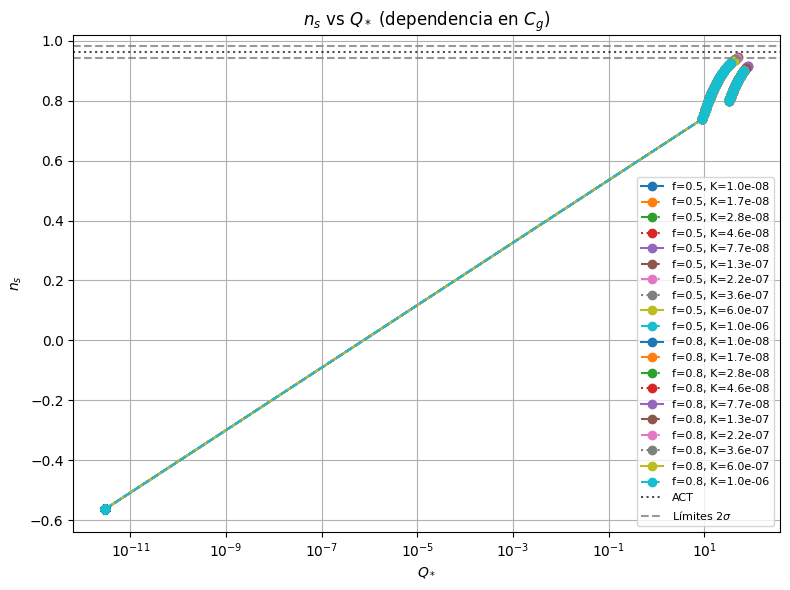

In [ ]:
plt.figure(figsize=(8,6))

# estilos de línea para distintos Ch
linestyles = ['-', '--', '-.', ':']

for f in resultados_escalares:
    
    Cg_vals = np.array(resultados_escalares[f]['Cg'])
    K_vals = np.array(resultados_escalares[f]['K'])
    ns_vals = np.array(resultados_escalares[f]['ns'])
    Q_vals  = np.array(resultados_escalares[f]['Q_star'])
    
    # valores únicos de Ch para este f
    K_unique = np.unique(K_vals)
    
    for i, K in enumerate(K_unique):
        
        mask = (K_vals == K)
        
        # seleccionar subconjunto
        Cg_sub = Cg_vals[mask]
        ns_sub = ns_vals[mask]
        Q_sub  = Q_vals[mask]
        
        # ordenar por Cg (importante para que la línea sea suave)
        order = np.argsort(Cg_sub)
        
        Cg_sub = Cg_sub[order]
        ns_sub = ns_sub[order]
        Q_sub  = Q_sub[order]
        
        linestyle = linestyles[i % len(linestyles)]
        
        label = f"f={f}, K={K:.1e}"
        
        plt.semilogx(Q_sub, ns_sub, linestyle=linestyle, marker='o', label=label)
ns_ACT = 0.964
sigma_ACT = 0.02 #2sigmas

plt.axhline(ns_ACT, color='black', linestyle=':', alpha=0.7, label='ACT')
plt.axhline(ns_ACT + sigma_ACT, color='gray', linestyle='--', alpha=0.8, label=r'Límites $2\sigma$')
plt.axhline(ns_ACT - sigma_ACT, color='gray', linestyle='--', alpha=0.8)
plt.xlabel(r"$Q_*$")
plt.ylabel(r"$n_s$")
plt.title(r"$n_s$ vs $Q_*$ (dependencia en $C_g$)")

plt.grid()
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

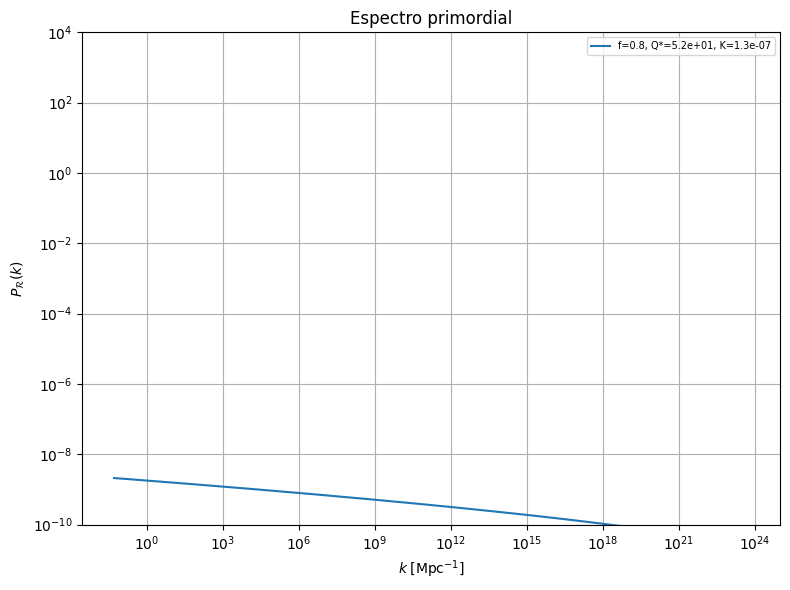

In [ ]:
plt.figure(figsize=(8,6))

for (f, Cg, K), data in evolucion_k.items():
    ns = data['ns_pivot']
    
    if not (ns_ACT - sigma_ACT <= ns <= ns_ACT + sigma_ACT):
        continue
    k  = data['k_ar']
    Pr = data['As']
    Qs = data['Q_star']
    
    label = f"f={f}, Q*={Qs:.1e}, K={K:.1e}"
    
    plt.loglog(k, Pr, label=label)

plt.xlabel(r"$k \; [\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P_\mathcal{R}(k)$")
plt.title("Espectro primordial")
plt.ylim(1e-10, 1e4)
plt.legend(fontsize=7)
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

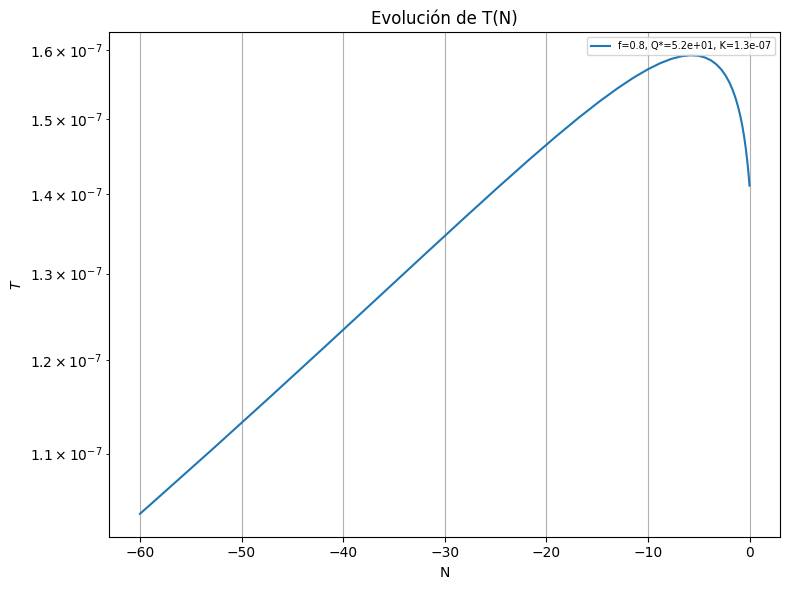

In [ ]:
plt.figure(figsize=(8,6))

for (f, Cg, K), data in evolucion_k.items():
    ns = data['ns_pivot']
    
    if not (ns_ACT - sigma_ACT <= ns <= ns_ACT + sigma_ACT):
        continue
    N_vals = data['N_vals']
    T_vals = data['T_N']
    Qs = data['Q_star']
    
    label = f"f={f}, Q*={Qs:.1e}, K={K:.1e}"
    
    plt.semilogy(N_vals, T_vals, label=label)

plt.xlabel("N")
plt.ylabel(r"$T$")
plt.title("Evolución de T(N)")

plt.legend(fontsize=7)
plt.grid()
plt.tight_layout()
plt.show()

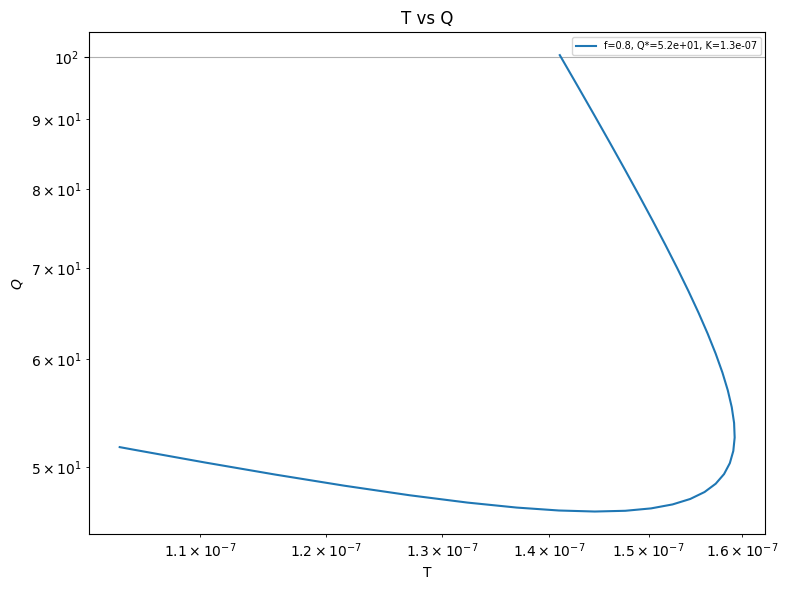

In [ ]:
plt.figure(figsize=(8,6))

for (f, Cg, K), data in evolucion_k.items():
    ns = data['ns_pivot']
    
    if not (ns_ACT - sigma_ACT <= ns <= ns_ACT + sigma_ACT):
        continue
    Q_vals = data['Q_N']
    T_vals = data['T_N']
    Qs = data['Q_star']
    
    label = f"f={f}, Q*={Qs:.1e}, K={K:.1e}"
    
    plt.loglog(T_vals, Q_vals, label=label)

plt.xlabel("T")
plt.ylabel(r"$Q$")
plt.title("T vs Q")

plt.legend(fontsize=7)
plt.grid()
plt.tight_layout()
plt.show()

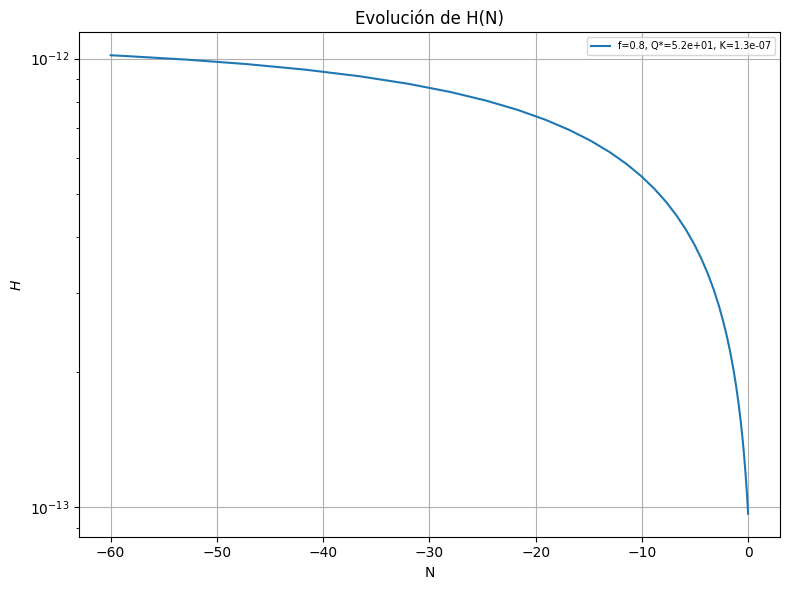

In [ ]:
plt.figure(figsize=(8,6))

for (f, Cg, K), data in evolucion_k.items():
    ns = data['ns_pivot']
    
    if not (ns_ACT - sigma_ACT <= ns <= ns_ACT + sigma_ACT):
        continue
    N_vals = data['N_vals']
    H_vals = data['H_N']
    Qs = data['Q_star']
    
    label = f"f={f}, Q*={Qs:.1e}, K={K:.1e}"
    
    plt.semilogy(N_vals, H_vals, label=label)

plt.xlabel("N")
plt.ylabel(r"$H$")
plt.title("Evolución de H(N)")

plt.legend(fontsize=7)
plt.grid()
plt.tight_layout()
plt.show()

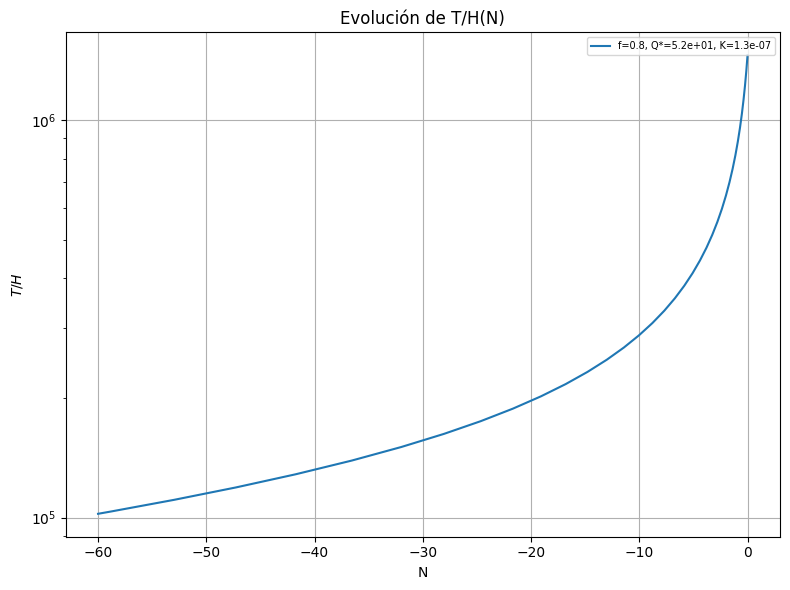

In [ ]:
plt.figure(figsize=(8,6))

for (f, Cg, K), data in evolucion_k.items():
    ns = data['ns_pivot']
    
    if not (ns_ACT - sigma_ACT <= ns <= ns_ACT + sigma_ACT):
        continue
    N_vals = data['N_vals']
    TH_vals = data['TH_N']
    Qs = data['Q_star']
    
    label = f"f={f}, Q*={Qs:.1e}, K={K:.1e}"
    
    plt.semilogy(N_vals, TH_vals, label=label)

plt.xlabel("N")
plt.ylabel(r"$T/H$")
plt.title("Evolución de T/H(N)")

plt.legend(fontsize=7)
plt.grid()
plt.tight_layout()
plt.show()

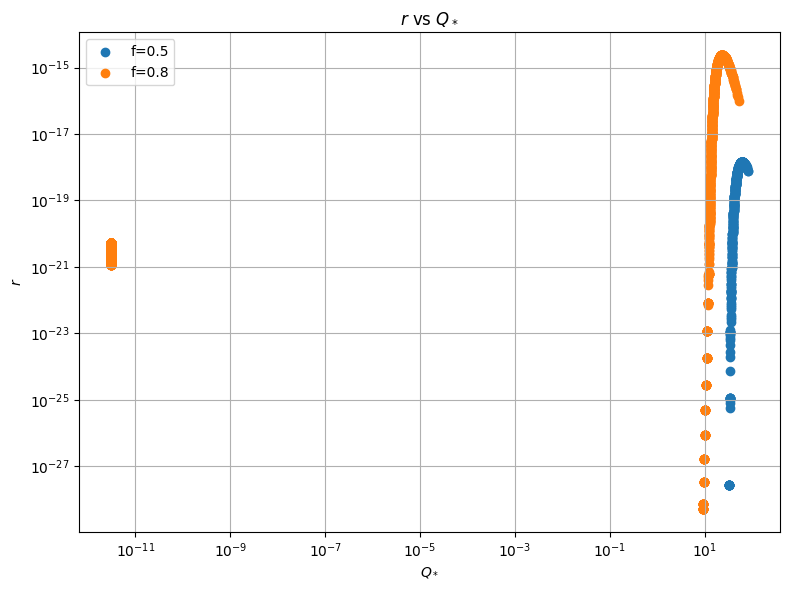

In [ ]:
plt.figure(figsize=(8,6))

for f in resultados_escalares:
    Q_vals = np.array(resultados_escalares[f]['Q_star'])
    r_vals = np.array(resultados_escalares[f]['r'])
    
    plt.scatter(Q_vals, r_vals, label=f"f={f}")

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$Q_*$")
plt.ylabel(r"$r$")
plt.title(r"$r$ vs $Q_*$")

plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

In [ ]:
import json

# Convertimos claves a strings
evolucion_k_serializable = {
    str(k): {key: (v.tolist() if isinstance(v, np.ndarray) else v) for key,v in val.items()}
    for k,val in evolucion_k.items()
}

# Guardar
with open("evolucion_k.json", "w") as f:
    json.dump(evolucion_k_serializable, f, indent=2)

# Guardar
with open("evolucion_k.json", "w") as f:
    json.dump(evolucion_k_serializable, f, indent=2)

# Cargar
with open("evolucion_k.json", "r") as f:
    evolucion_k_loaded = json.load(f)

# Convertir listas a arrays si se necesita
for k, val in evolucion_k_loaded.items():
    for key in ['N_vals', 'phi_N', 'Q_N', 'TH_N', 'k_ar', 'As', 'ns', 'Pr', 'T_N', 'H_N']:
        val[key] = np.array(val[key])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==========================================
# 1. FUNCIÓN PRINCIPAL DEL APPLET
# ==========================================
def calcular_y_graficar(b):
    # Limpiamos el panel de salida para actualizar la gráfica
    with out:
        clear_output(wait=True)
        
        # Recogemos los valores de los sliders
        f = slider_f.value
        Cg = 10**slider_Cg_log.value
        K = 10**slider_K_log.value
        
        print(f"Calculando para f = {f}, Cg = {Cg:.2e}, K = {K:.2e} ... por favor espera.")
        
        try:
            # Constantes base
            Mpl = 1
            g = 106.75
            c = 3
            m = 0
            kpivot = 0.05
            
            # --- Background ---
            # Llamamos a tu función principal (el orden de parámetros K y Cg debe coincidir)
            M, N_vals, phi_N, Q_N, TH_N, T_N, H_N = find_M(f, Cg, K)
            
            phi_star = phi_N[0]
            Q_star   = Q_N[0]
            
            # --- Observables en la escala pivote ---
            G3 = 1 + 4.981*Q_star**1.946 + 0.127*Q_star**4.33
            dlnG3 = ((4.981*1.946)*Q_star**0.946 + (0.127*4.33)*Q_star**3.33)/G3
            
            pt = espectro_tensorial(phi_star, f, M, Mpl)
            ps = espectro_potencias(phi_star, Q_star, f, M, Mpl, g, c, K, G3)
            r_tensor = pt/ps
            ns = indice_espectral(phi_star, Q_star, f, M, Mpl, g, c, m, K, dlnG3)
            
            # --- Evolución dependiente de N ---
            HN = np.array([Hubble(phi, f, M, Mpl) for phi in phi_N])
            k_ar = np.array([kpivot * np.exp(N+60) * (H/HN[0]) for N, H in zip(N_vals, HN)])
            
            As_array = []
            ns_array = []
            for phi, Q in zip(phi_N, Q_N):
                G3_q = 1 + 4.981*Q**1.946 + 0.127*Q**4.33
                dlnG3_q = ((4.981*1.946)*Q**0.946 + (0.127*4.33)*Q**3.33)/G3_q
                
                As_array.append(espectro_potencias(phi, Q, f, M, Mpl, g, c, K, G3_q))
                ns_array.append(indice_espectral(phi, Q, f, M, Mpl, g, c, m, K, dlnG3_q))
                
            As_array = np.array(As_array)
            ns_array = np.array(ns_array)
            Pr_ar = As_array * (k_ar/kpivot)**(ns_array - 1)
            
            # --- Resultados numéricos ---
            print("-" * 40)
            print("  PARÁMETROS OBSERVACIONALES (Pivote)")
            print("-" * 40)
            print(f" Masa (M)   = {M:.4e}")
            print(f" Q_star     = {Q_star:.4e}")
            print(f" n_s        = {ns:.5f}")
            print(f" r          = {r_tensor:.4e}")
            print(f" A_s        = {ps:.4e}")
            print("-" * 40)
            
            # --- Gráficas ---
            fig, ax = plt.subplots(1, 2, figsize=(14, 5))
            
            # Gráfica 1: Espectro
            ax[0].plot(k_ar, Pr_ar, color='darkblue', lw=2)
            ax[0].set_xscale('log')
            ax[0].set_yscale('log')
            ax[0].set_xlabel(r'$k \ [\mathrm{Mpc}^{-1}]$')
            # CORRECCIÓN AQUÍ: \mathcal{P}_{\mathcal{R}} en lugar de \mathcal{P_R}
            ax[0].set_ylabel(r'$\mathcal{P}_{\mathcal{R}}(k)$')
            ax[0].set_title('Espectro de Potencias vs Escala k')
            ax[0].grid(True, which="both", ls="--", alpha=0.5)
            
            # Gráfica 2: Evolución de Q
            ax[1].plot(N_vals, Q_N, color='darkred', lw=2)
            ax[1].set_xlabel(r'$N \ (\mathrm{e-folds})$')
            ax[1].set_ylabel(r'$Q$')
            ax[1].set_yscale('log')
            ax[1].set_title('Evolución de Disipación Q')
            ax[1].grid(True, which="both", ls="--", alpha=0.5)
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"\n[!] Error en el cálculo con esta configuración: {type(e).__name__}: {e}")
            print("Verifica que las ecuaciones convergen para estos parámetros.")
# ==========================================
# 2. DEFINICIÓN DE LA INTERFAZ GRÁFICA
# ==========================================
# Deslizadores para los parámetros
slider_f = widgets.FloatSlider(value=1.5, min=1.0, max=10.0, step=0.1, description='f:')

# Para Cg y K usamos escalas logarítmicas (base 10) por los amplios rangos que manejas
slider_Cg_log = widgets.FloatSlider(value=5.0, min=3.0, max=10.0, step=0.1, description='log10(Cg):')
slider_K_log = widgets.FloatSlider(value=-2.0, min=-4.0, max=-1.0, step=0.1, description='log10(K):')

# Botón de cálculo
btn_calcular = widgets.Button(
    description='Calcular Espectro',
    button_style='info', 
    tooltip='Ejecuta el modelo con los parámetros actuales',
    icon='play'
)

# Panel donde saldrán los resultados
out = widgets.Output()

# Asignar la función de cálculo al botón
btn_calcular.on_click(calcular_y_graficar)

# Organizar visualmente (cajas)
ui_inputs = widgets.VBox([slider_f, slider_Cg_log, slider_K_log, btn_calcular])

# Mostrar todo en pantalla
display(ui_inputs, out)

Output()